# 00 — Training the 2D autoencoder

**Series:** field-controlled generation in 2D · notebook 0 of 5

Everything in this tutorial series happens in the **latent space** of a variational
autoencoder. Before we can talk about porosity fields, conditioning or chunk decoding,
we need that autoencoder. This notebook trains it and — more importantly — establishes
the three properties the rest of the series depends on.

| property | why the method needs it |
|---|---|
| **compression $F=8$, $C_\ell=4$** | the conditioning field is consumed at *latent* resolution, so a $256^2$ patch becomes a $32^2$ field |
| **no self-attention anywhere** | a fully convolutional decoder has a **finite receptive field**, which is what makes tiled (chunk) decoding exact — notebook 05 |
| **generalises past its training size** | trained on $128^2$ patches, used on $512^2$ and larger at inference |

This mirrors the thesis autoencoder exactly, one dimension down: 3D uses $F=8$, $C_\ell=4$,
trained on $64^3$ subvolumes and applied at $256^3$ and beyond.

> **Rock.** Berea sandstone, `Berea_2d25um_binary.raw`, a $1000^3$ binary volume at
> $2.25\,\mu$m. Convention throughout the series: **solid = 1, pore = 0**, so porosity
> is `1 - mean`.

---
## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
import lightning
import lightning.pytorch.callbacks as pl_callbacks

import diffsci2.data
import diffsci2.models
import diffsci2.nets

import fcconfig as fc

fc.ensure_dirs()
torch.manual_seed(0)
np.random.seed(0)

DEVICE = fc.DEVICE
print(f"device        = {DEVICE}")
print(f"patch (VAE)   = {fc.VAE_PATCH}")
print(f"compression F = {fc.F}   latent channels = {fc.Z_DIM}")

device        = cuda:2
patch (VAE)   = 128
compression F = 8   latent channels = 4


In [3]:
# --- training knobs (small: this is a tutorial autoencoder, not a production one) ---
BATCH_SIZE = 32
DATASET_SIZE = 2 ** 13      # patches drawn per epoch
MAX_EPOCHS = 40
LR = 2e-4

RETRAIN = False             # set True to force a fresh run even if a checkpoint exists
CKPT = os.path.join(fc.VAE_CKPT_DIR, "last.ckpt")
print(f"checkpoint -> {CKPT}   (exists: {os.path.exists(CKPT)})")

checkpoint -> /home/ubuntu/repos/DiffSci2/notebooks/tutorials/fieldcontrolling/fcdata/checkpoints/vae/last.ckpt   (exists: False)


---
## 2. The data

`VolumeSubsliceDataset` draws a random slice from the volume, then a random
$128^2$ window inside that slice, then applies one of the **8 symmetries of the
square** ($D_4$: four rotations, four reflections). In 3D the same augmentation
uses the 48 symmetries of the cube.

In [4]:
volume = np.fromfile(fc.RAW_PATH, dtype=np.uint8).reshape(fc.VOLUME_SHAPE)
print(f"volume   : {volume.shape}, values {np.unique(volume)}")
print(f"porosity : {fc.porosity_of(volume):.4f}  (pore fraction, solid = 1)")

volume   : (1000, 1000, 1000), values [0 1]


porosity : 0.2167  (pore fraction, solid = 1)


In [5]:
symmetry = diffsci2.data.SquareSymmetry()


class UnconditionalDataset(torch.utils.data.Dataset):
    '''VolumeSubsliceDataset -> {'x': tensor}, the format the modules expect.'''

    def __init__(self, base):
        self.base = base

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x = self.base[idx]
        if isinstance(x, dict):
            x = x['x']
        return {'x': x}


base = diffsci2.data.VolumeSubsliceDataset(
    volume,
    subslice_size=fc.VAE_PATCH,
    dataset_size=DATASET_SIZE,
    square_symmetry=symmetry,
    return_as_dict=False,
)
dataset = UnconditionalDataset(base)
dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, persistent_workers=True,
)
print(f"patches per epoch : {len(dataset)}")

patches per epoch : 8192


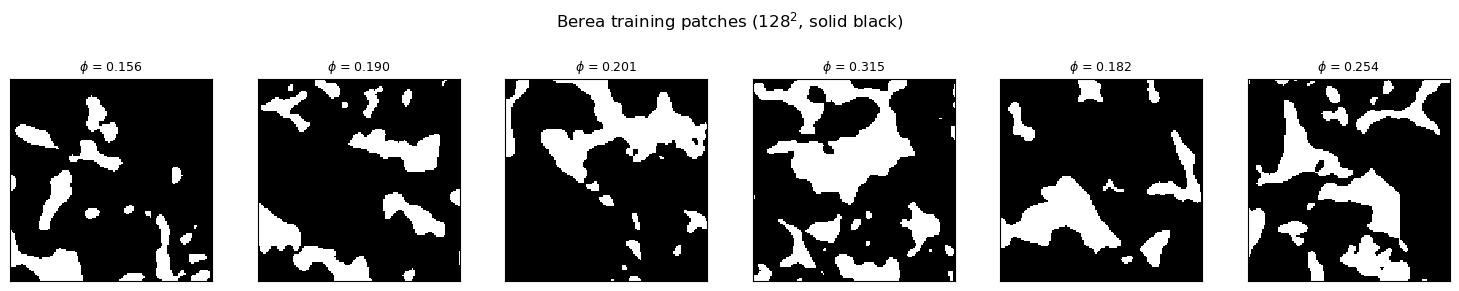

In [6]:
# A look at what the network actually sees.
batch = next(iter(dataloader))['x']
fig, axes = plt.subplots(1, 6, figsize=(15, 2.7))
for ax, img in zip(axes, batch):
    ax.imshow(img[0], cmap='gray_r', interpolation='nearest')
    ax.set_title(f"$\\phi$ = {1 - img.mean():.3f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Berea training patches ({fc.VAE_PATCH}$^2$, solid black)", y=1.06)
fig.tight_layout()
fc.savefig(fig, "00_training_patches")
plt.show()

Note the spread in the per-patch porosity $\phi$ already visible in the titles.
That spread is the whole subject of this tutorial series: it is *not* noise, it is
**spatial heterogeneity of the rock**, and notebook 01 turns it into a field.

---
## 3. The autoencoder

Three downsampling levels (`ch_mult = [1, 2, 4, 4]` — the VAE downsamples at every
level but the last) give $F = 2^3 = 8$. A $128^2$ patch encodes to a
$4\times16\times16$ latent; the $256^2$ patches used by the diffusion model in
notebooks 02–05 encode to $4\times32^2$.

`has_mid_attn=False` and `attn_resolutions=[]` are not a performance choice — they
are a **correctness requirement** for notebook 05. Attention couples every output
pixel to every input pixel, so a decoder with attention has an infinite receptive
field and cannot be tiled.

In [7]:
vae_module = fc.make_vae()
nparams = sum(p.numel() for p in vae_module.parameters())
print(f"VAE parameters: {nparams / 1e6:.2f}M")

# Confirm the compression factor empirically rather than trusting the arithmetic.
with torch.no_grad():
    probe = torch.rand(1, 1, fc.PATCH, fc.PATCH).round()
    z_probe = vae_module.encode(probe)['zsample']
print(f"{tuple(probe.shape)} -> {tuple(z_probe.shape)}   F = {probe.shape[-1] // z_probe.shape[-1]}")

VAE parameters: 5.12M
(1, 1, 256, 256) -> (1, 4, 32, 32)   F = 8


In [8]:
if RETRAIN or not os.path.exists(CKPT):
    optimizer = torch.optim.AdamW(vae_module.parameters(), lr=LR)
    vae_module.set_optimizer_and_scheduler(optimizer)

    trainer = lightning.Trainer(
        max_epochs=MAX_EPOCHS,
        default_root_dir=fc.VAE_CKPT_DIR,
        gradient_clip_val=0.5,
        callbacks=[
            diffsci2.models.NanToZeroGradCallback(),
            pl_callbacks.ModelCheckpoint(
                dirpath=fc.VAE_CKPT_DIR, filename='vae-{epoch:03d}', save_last=True,
            ),
        ],
        enable_checkpointing=True,
        devices=[int(DEVICE.split(':')[1])],
        logger=False,
    )
    t0 = time.time()
    trainer.fit(vae_module, dataloader)
    print(f"trained in {(time.time() - t0) / 60:.1f} min")
else:
    print("checkpoint found, skipping training (set RETRAIN = True to force)")

vae = fc.load_vae(CKPT, device=DEVICE)
print("VAE ready")

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


/opt/persistence/miniconda3/envs/ddpm_env/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


...


  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | encdec       | VAENet            | 5.1 M  | train
1 | loss_module  | VAELoss           | 0      | train
2 | initial_norm | IdentityBatchNorm | 0      | train
-----------------------------------------------------------
5.1 M     Trainable params
0         Non-trainable params
5.1 M     Total params
20.475    Total estimated model params size (MB)
263       Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=40` reached.


trained in 19.6 min


VAE ready


---
## 4. Data $\to$ latent $\to$ data

The middle panels show the four latent channels. They are a $16\times$ smaller,
smooth, continuous representation of a binary image — which is precisely why running
diffusion there is cheap, and why a *coarse* conditioning field can be attached to it
without any resolution mismatch.

In [9]:
@torch.no_grad()
def reconstruct(vae, img):
    '''img: [H, W] float in {0,1}  ->  (latent [C,h,w], reconstruction [H,W])'''
    x = torch.tensor(img, dtype=torch.float32, device=DEVICE)[None, None]
    z = vae.encode(x)['zsample']
    xr = vae.decode(z)
    return z[0].cpu().numpy(), xr[0, 0].cpu().numpy()


test_patch = volume[500, 300:300 + fc.PATCH, 300:300 + fc.PATCH].astype(np.float32)
z_np, recon = reconstruct(vae, test_patch)
recon_bin = (recon > recon.mean()).astype(np.float32)

print(f"latent shape       : {z_np.shape}")
print(f"input porosity     : {1 - test_patch.mean():.4f}")
print(f"recon porosity     : {1 - recon_bin.mean():.4f}")
print(f"voxel agreement    : {(recon_bin == test_patch).mean():.4f}")

latent shape       : (4, 32, 32)
input porosity     : 0.1918
recon porosity     : 0.1938
voxel agreement    : 0.9980


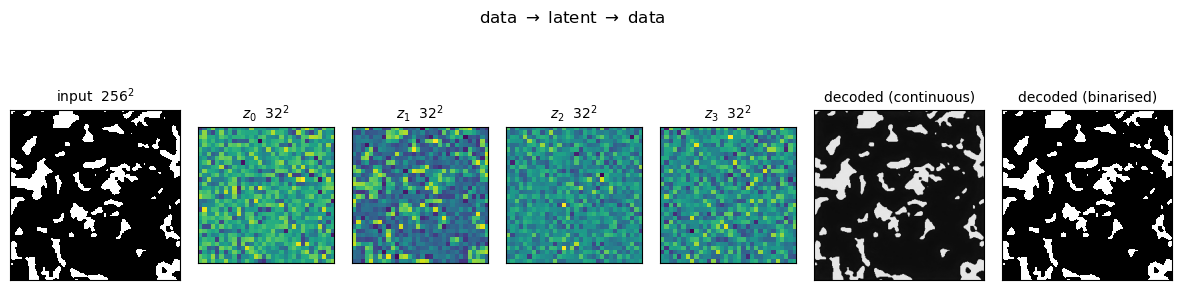

In [10]:
fig = plt.figure(figsize=(15, 3.4))
gs = fig.add_gridspec(1, 7, width_ratios=[1.25, 1, 1, 1, 1, 1.25, 1.25], wspace=0.12)

ax = fig.add_subplot(gs[0]); ax.imshow(test_patch, cmap='gray_r', interpolation='nearest')
ax.set_title(f"input  {fc.PATCH}$^2$", fontsize=10)

for c in range(fc.Z_DIM):
    ax = fig.add_subplot(gs[1 + c])
    ax.imshow(z_np[c], cmap='viridis')
    ax.set_title(f"$z_{c}$  {z_np.shape[-1]}$^2$", fontsize=10)

ax = fig.add_subplot(gs[5]); ax.imshow(recon, cmap='gray_r')
ax.set_title("decoded (continuous)", fontsize=10)
ax = fig.add_subplot(gs[6]); ax.imshow(recon_bin, cmap='gray_r', interpolation='nearest')
ax.set_title("decoded (binarised)", fontsize=10)

for ax in fig.axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("data $\\to$ latent $\\to$ data", y=1.04)
fc.savefig(fig, "00_autoencoder_roundtrip")
plt.show()

### Binarisation

The decoder emits continuous values; the pipeline binarises with the **per-volume mean
threshold**, `x > x.mean()`. This is the same rule used in `0004e-porosity-field-generator.py`.
It is worth seeing why it is not innocuous: the threshold is a *global* statistic, so a
volume with strong large-scale porosity variation has its threshold set by the whole
volume, not locally.

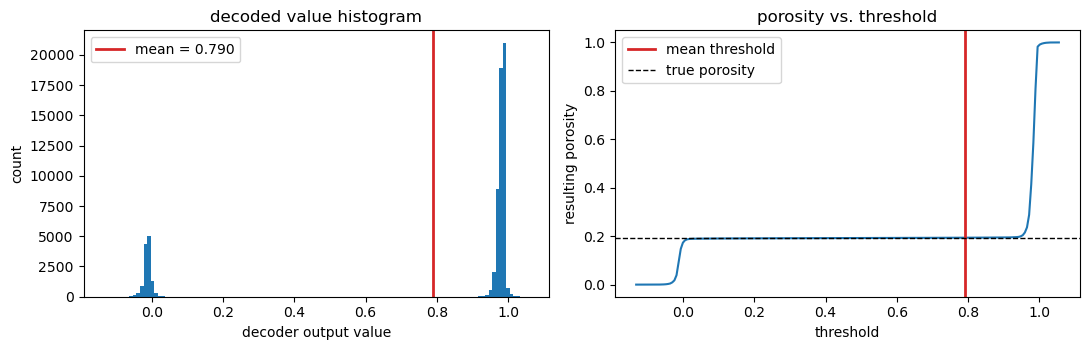

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(recon.ravel(), bins=120, color='C0')
axes[0].axvline(recon.mean(), color='C3', lw=2, label=f"mean = {recon.mean():.3f}")
axes[0].set_xlabel("decoder output value"); axes[0].set_ylabel("count")
axes[0].set_title("decoded value histogram"); axes[0].legend()

thresholds = np.linspace(recon.min(), recon.max(), 200)
porosities = [(recon <= t).mean() for t in thresholds]
axes[1].plot(thresholds, porosities, color='C0')
axes[1].axvline(recon.mean(), color='C3', lw=2, label='mean threshold')
axes[1].axhline(1 - test_patch.mean(), color='k', ls='--', lw=1, label='true porosity')
axes[1].set_xlabel("threshold"); axes[1].set_ylabel("resulting porosity")
axes[1].set_title("porosity vs. threshold"); axes[1].legend()
fig.tight_layout()
fc.savefig(fig, "00_binarisation")
plt.show()

---
## 5. Generalisation beyond the training size

The autoencoder saw only $128^2$ patches. Because it is fully convolutional, it can be
applied to any input whose size is divisible by $F = 8$. The thesis relies on this
twice: the diffusion model is trained on $256$-sized patches encoded by a VAE trained
on $64$-sized ones, and inference decodes volumes far larger than anything seen in
training.

Below we run the round trip at four sizes and check that reconstruction quality does
not degrade.

In [12]:
sizes = [128, 256, 512, 1024]
rows = []
for s in sizes:
    patch = volume[500, :s, :s].astype(np.float32)
    _, rec = reconstruct(vae, patch)
    rec_bin = (rec > rec.mean()).astype(np.float32)
    rows.append({
        'size': s,
        'phi_true': 1 - patch.mean(),
        'phi_recon': 1 - rec_bin.mean(),
        'agreement': (rec_bin == patch).mean(),
    })

print(f"{'size':>6} {'phi true':>10} {'phi recon':>10} {'agreement':>10}")
for r in rows:
    print(f"{r['size']:>6} {r['phi_true']:>10.4f} {r['phi_recon']:>10.4f} {r['agreement']:>10.4f}")

  size   phi true  phi recon  agreement
   128     0.2583     0.2601     0.9972
   256     0.2356     0.2375     0.9977
   512     0.2031     0.2050     0.9980
  1024     0.2016     0.2036     0.9978


In [ ]:
fig, axes = plt.subplots(2, len(sizes), figsize=(3.2 * len(sizes), 6.6))
for k, s in enumerate(sizes):
    patch = volume[500, :s, :s].astype(np.float32)
    _, rec = reconstruct(vae, patch)
    rec_bin = (rec > rec.mean()).astype(np.float32)
    axes[0, k].imshow(patch, cmap='gray_r', interpolation='nearest')
    axes[0, k].set_title(f"original  {s}$^2$", fontsize=10)
    axes[1, k].imshow(rec_bin, cmap='gray_r', interpolation='nearest')
    axes[1, k].set_title(f"round trip  ({rows[k]['agreement']:.3f} agree)", fontsize=10)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("The VAE was trained only on $128^2$ patches", y=1.0)
fig.tight_layout()
fig.subplots_adjust(hspace=0.22)   # room for the row-2 titles
fc.savefig(fig, "00_size_generalisation")
plt.show()

---
## What to carry forward

- The VAE is a frozen $F=8$, $C_\ell=4$ compressor. From here on it is never trained again;
  notebooks 02–05 only ever call `encode` and `decode`.
- A $256^2$ patch $\leftrightarrow$ a $4\times 32^2$ latent. **The conditioning field will
  live on that $32^2$ grid.**
- The decoder is attention-free, so its receptive field is finite. Notebook 05 turns that
  into tiled decoding of volumes far too large to fit on a GPU.

**Next:** `01-porosity-field-and-gaussian-process.ipynb` — what a porosity field *is*, how
to compute it, and how to fit the Gaussian process that generates new ones.